# Dr.Copper — Phase 6: Monte Carlo, Risk and Derivatives

In [1]:
import numpy as np
import pandas as pd

import dr_copper as dc
from pathlib import Path
import QuantLib as ql
import matplotlib.pyplot as plt

%matplotlib inline

import warnings

warnings.filterwarnings("ignore")

DATA = Path("../data")

## 1 — Load previous Phases outputs

In [2]:
features_with_vol = pd.read_parquet(DATA / "processed" / "features_with_vol.parquet")
raw = pd.read_parquet(DATA / "raw" / "raw_test.parquet")

end_date = features_with_vol.index[-1]

In [3]:
sigma_hat = float(features_with_vol["garch_vol_ann"].iloc[-1])
theta_vol_longrun = float(features_with_vol["garch_vol_ann"].mean())
persistence_mean = float(features_with_vol["persistence"].mean())
S0 = float(raw["copper"].loc[end_date])

print(f"Spot (S0):                  {S0:.4f}")
print(f"Last GARCH sigma-hat:       {sigma_hat:.4%}  (annualized)")
print(f"Long-run mean GARCH vol:    {theta_vol_longrun:.4%}")
print(f"Persistence mean GARCH:     {persistence_mean:.2f}")

Spot (S0):                  6.3420
Last GARCH sigma-hat:       29.5544%  (annualized)
Long-run mean GARCH vol:    22.9069%
Persistence mean GARCH:     0.98


## 2 — Monte Carlo

In [4]:
n_paths = 10_000
n_steps = 63
dt = 1 / 252
mu = 0.0  # risk-neutral drift assumption

### GBM


Geometric Brownian Motion under a risk-neutral drift (we set $\mu = r - q = 0$; this is a modeling assumption):

$$dS_t = \mu S_t\,dt + \hat\sigma S_t\,dW_t$$

We simulate 10,000 paths, 63 trading days
ahead, on a daily grid.

In [5]:
gbm_paths = dc.gbm(n_paths, n_steps, mu, sigma_hat, dt, S0)

gbm_terminal = gbm_paths[:, -1]

print(
    f"GBM terminal price: mean={gbm_terminal.mean():.4f}, std={gbm_terminal.std():.4f}"
)
print(
    f"GBM terminal 5th/95th pct: {np.percentile(gbm_terminal, 5):.4f} / {np.percentile(gbm_terminal, 95):.4f}"
)

GBM terminal price: mean=6.3328, std=0.9423
GBM terminal 5th/95th pct: 4.9019 / 7.9469


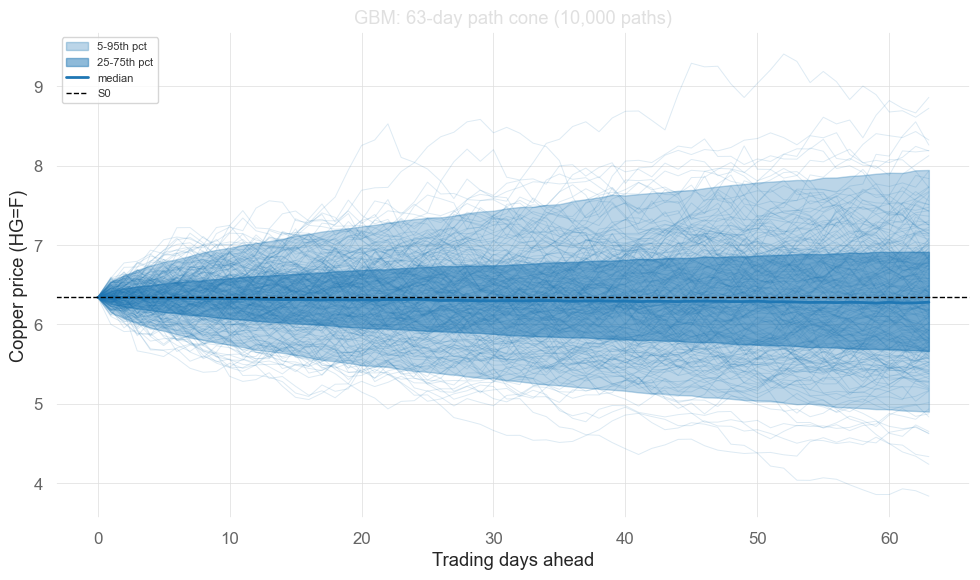

In [6]:
dc.plot_cone(gbm_paths, S0, "GBM: 63-day path cone (10,000 paths)", "tab:blue")
plt.tight_layout()
plt.show()

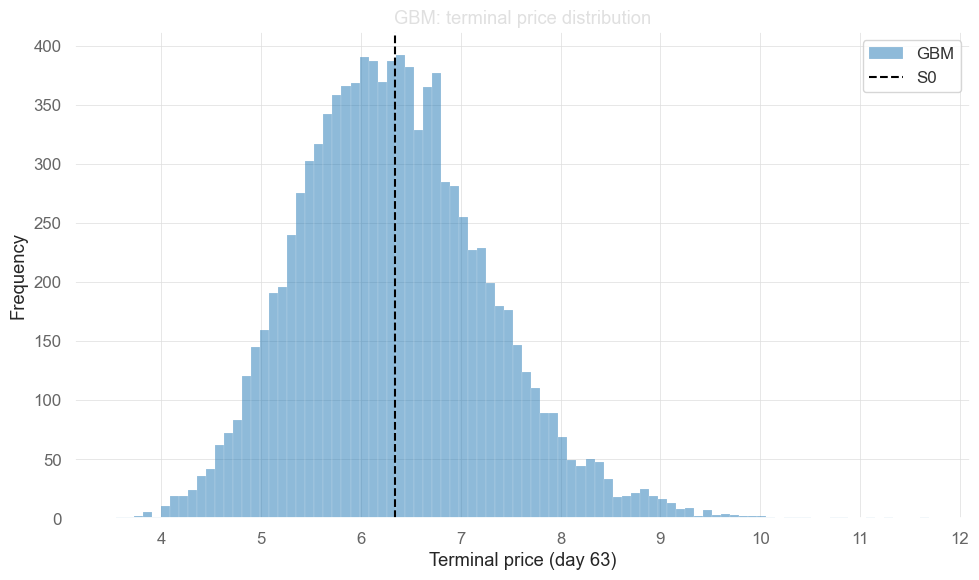

In [7]:
dc.plot_distrib(gbm_terminal, "GBM", S0, "GBM: terminal price distribution")
plt.tight_layout()
plt.show()

### Heston model

GBM assumes constant volatility. We saw that Copper vol is not constant, so we also simulate under Heston stochastic volatility:

$$dS_t = \mu\,S_t\,dt + S_t\sqrt{v_t}\,dW_t^S, \qquad dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v, \qquad d\langle W^S, W^v\rangle_t = \rho\,dt$$

Some of the Heston parameters can be obtained from the results of our previous GARCH model, at least approximately. We use the GARCH results to obtain representative values for $\kappa$, $\theta$, and $v_0$. In particular, $\kappa$ is related to the persistence of the GARCH model, $\alpha+\beta$.

The remaining parameters, $\xi$ (volatility of variance) and $\rho$ (correlation between price and variance), are taken from the literature.

The source uses trapezoidal fuzzy numbers to represent uncertainty in the Heston parameters. Since we use the standard (non-fuzzy) Heston model, we need one value for each parameter. We therefore use the midpoint of the core interval, $(b+c)/2$, for the parameters taken from the source. 

The purpose of this section is mainly to demonstrate the Heston model and its application to copper prices. It is not intended to provide the most precise parameter calibration or the best possible simulation results. Therefore, the aim is to use reasonable and literature-based parameter values that allow us to demonstrate the model.

In [8]:
kappa = -252 * np.log(persistence_mean)
theta = theta_vol_longrun**2  # long-run *variance*
v0 = sigma_hat**2

xi = 0.62
rho = -0.65

r_rate, q_rate = 0.0, 0.0

feller_lhs, feller_rhs = 2 * kappa * theta, xi**2
print(f"v0={v0:.5f}  theta={theta:.5f}  kappa={kappa:.5f}  xi={xi}  rho={rho}")
print(
    f"Feller condition 2*kappa*theta > xi^2 : {feller_lhs:.4f} > {feller_rhs:.4f} -> {feller_lhs > feller_rhs}"
)

v0=0.08735  theta=0.05247  kappa=4.31083  xi=0.62  rho=-0.65
Feller condition 2*kappa*theta > xi^2 : 0.4524 > 0.3844 -> True


The Heston variance process is a CIR process and we checked the Feller condition $2\kappa\theta > \xi^2$, that allows us to say that the variance process is less likely to hit zero.

In [9]:
heston_paths = dc.heston(
    n_paths, n_steps, v0, kappa, theta, xi, rho, r_rate, q_rate, S0
)

heston_terminal = heston_paths[:, -1]
print(
    f"Heston terminal price: mean={heston_terminal.mean():.4f}, std={heston_terminal.std():.4f}"
)
print(
    f"Heston terminal 5th/95th pct: {np.percentile(heston_terminal, 5):.4f} / {np.percentile(heston_terminal, 95):.4f}"
)

Heston terminal price: mean=6.3440, std=0.8396
Heston terminal 5th/95th pct: 4.8722 / 7.6301


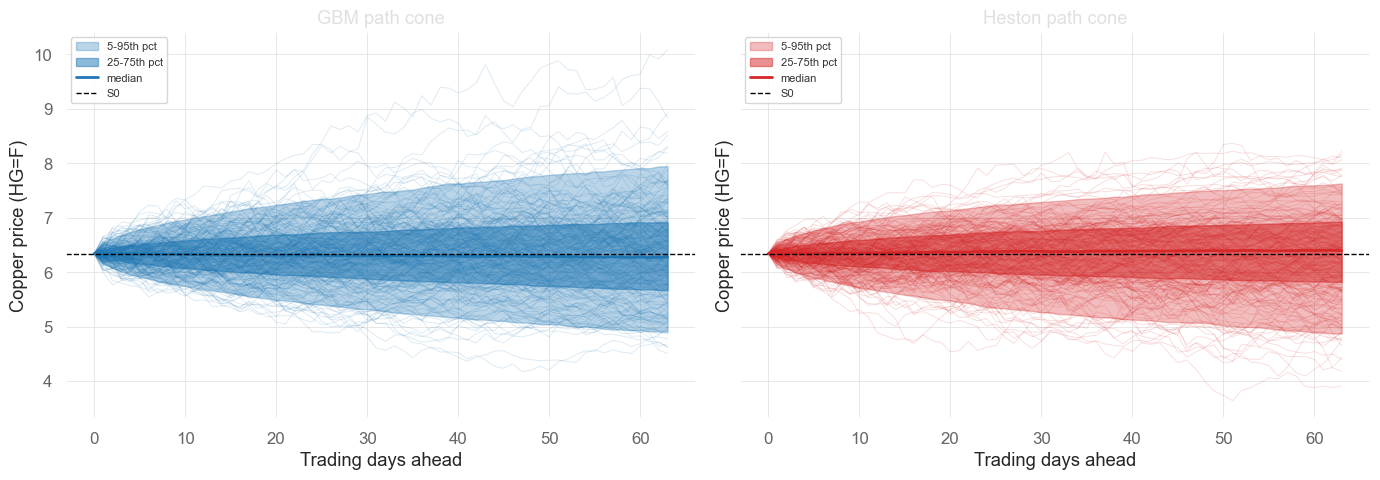

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
dc.plot_cone(gbm_paths, S0, "GBM path cone", "tab:blue", ax=axes[0])
dc.plot_cone(heston_paths, S0, "Heston path cone", "tab:red", ax=axes[1])
plt.tight_layout()
plt.show()

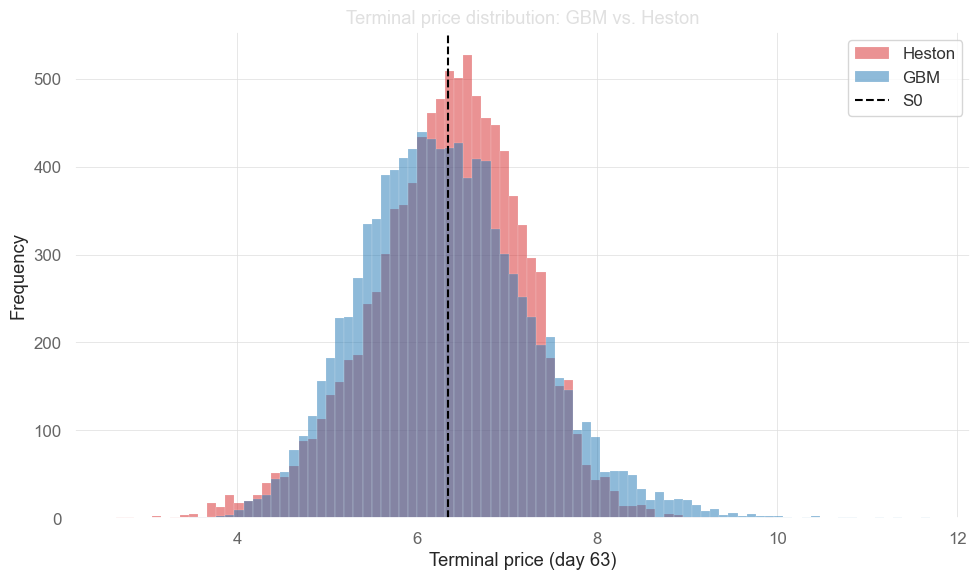

In [11]:
dc.plot_distrib(
    gbm_terminal,
    "GBM",
    S0,
    "Terminal price distribution: GBM vs. Heston",
    heston_terminal,
    "Heston",
)
plt.tight_layout()
plt.show()

## 3 — Risk metrics — VaR / CVaR, GBM vs. Heston

In [12]:
def var_cvar(terminal_prices, S0, alpha):
    returns = terminal_prices / S0 - 1.0
    var = np.quantile(returns, 1 - alpha)
    tail = returns[returns <= var]
    cvar = tail.mean() if len(tail) else var
    return abs(var), abs(cvar)

In [13]:
rows = []
for alpha in [0.95, 0.99]:
    gbm_var, gbm_cvar = var_cvar(gbm_terminal, S0, alpha)
    hes_var, hes_cvar = var_cvar(heston_terminal, S0, alpha)
    rows.append(
        {
            "Confidence": f"{int(alpha * 100)}%",
            "GBM VaR": gbm_var,
            "Heston VaR": hes_var,
            "VaR Δ (%)": (hes_var - gbm_var) / gbm_var * 100,
            "GBM CVaR": gbm_cvar,
            "Heston CVaR": hes_cvar,
            "CVaR Δ (%)": (hes_cvar - gbm_cvar) / gbm_cvar * 100,
        }
    )

In [14]:
risk_table = pd.DataFrame(rows).set_index("Confidence")
risk_table.style.format(
    {
        "GBM VaR": "{:.2%}",
        "Heston VaR": "{:.2%}",
        "VaR Δ (%)": "{:+.1f}%",
        "GBM CVaR": "{:.2%}",
        "Heston CVaR": "{:.2%}",
        "CVaR Δ (%)": "{:+.1f}%",
    }
)

,GBM VaR,Heston VaR,VaR Δ (%),GBM CVaR,Heston CVaR,CVaR Δ (%)
Confidence,,,,,,
95%,22.71%,23.18%,+2.1%,27.42%,30.09%,+9.7%
99%,30.34%,34.87%,+14.9%,33.84%,39.70%,+17.3%


GBM underestimates tail risk relative to stochastic volatility:
- at 95% confidence, Heston CVaR is +9.7% higher than GBM CVaR;
- at 99% confidence, Heston VaR is +14.9% higher than GBM VaR, and Heston CVaR is +17.3% higher.

The difference widens further out in the tail (99% > 95%). Vol-of-vol in the Heston model and negative price/vol correlation fatten the left tail more than a fixed sigma does in GBM.

## 4 — QuantLib option pricing (Black-Scholes)

We construct an ATM European straddle by buying a call and a put with the same strike price and expiration date. The strike is set equal to the current asset price, so the options are at-the-money. We use the Black–Scholes–Merton model with the estimated volatility. The risk-free rate and dividend yield are still 0, as they were for the Heston model in the MC section.

In [15]:
today = ql.Date().todaysDate()
ql.Settings.instance().evaluationDate = today
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
risk_free_ts = ql.YieldTermStructureHandle(ql.FlatForward(today, r_rate, day_count))
dividend_ts = ql.YieldTermStructureHandle(ql.FlatForward(today, q_rate, day_count))

expiry_days = 63
expiry_date = calendar.advance(today, ql.Period(expiry_days, ql.Days))
strike = S0  # ATM

vol_ts = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(today, calendar, sigma_hat, day_count)
)
bs_process = ql.BlackScholesMertonProcess(
    spot_handle, dividend_ts, risk_free_ts, vol_ts
)
bs_engine = ql.AnalyticEuropeanEngine(bs_process)

exercise = ql.EuropeanExercise(expiry_date)
call_option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call, strike), exercise)
put_option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Put, strike), exercise)
call_option.setPricingEngine(bs_engine)
put_option.setPricingEngine(bs_engine)

option_summary = pd.DataFrame(
    {
        "Call": [
            call_option.NPV(),
            call_option.delta(),
            call_option.gamma(),
            call_option.vega(),
            call_option.theta(),
        ],
        "Put": [
            put_option.NPV(),
            put_option.delta(),
            put_option.gamma(),
            put_option.vega(),
            put_option.theta(),
        ],
    },
    index=["NPV", "Delta", "Gamma", "Vega", "Theta"],
)

In [16]:
print(
    f"Spot={S0:.4f}  Strike(ATM)={strike:.4f}  sigma_hat={sigma_hat:.4%}  T={expiry_days}d"
)
option_summary.style.format()

Spot=6.3420  Strike(ATM)=6.3420  sigma_hat=29.5544%  T=63d


,Call,Put
NPV,0.310462,0.310462
Delta,0.524477,-0.475523
Gamma,0.511352,0.511352
Vega,1.049160,1.049160
Theta,-0.898226,-0.898226


The Greeks measure how sensitive an option's value is to changes in different factors. Delta measures sensitivity to the underlying price, Gamma measures how Delta changes, Vega measures sensitivity to volatility, and Theta measures sensitivity to the passage of time. They are useful for understanding and managing the risks of an option position.

## 5 — SABR calibration to a synthetic vol smile

In practice, the usual workflow starts with market option prices. For each option, we observe its strike, expiry, and market price, and then invert an option-pricing model (e.g. Black-Scholes/Black-76) to obtain the implied volatility. Repeating this across strikes gives a market volatility smile.

The next step is to calibrate a model such as SABR to these observed implied volatilities. SABR provides a smooth mathematical representation of the smile through its parameters ($\alpha, \beta, \nu\, and\, \rho$). Once calibrated, it can be used to interpolate implied volatility between quoted strikes, estimate volatility for unquoted strikes, and analyze changes in the shape of the smile.
$$
\text{Market prices}
\rightarrow
\text{Implied volatilities}
\rightarrow
\text{SABR calibration}
\rightarrow
\text{SABR volatility surface}
$$

Real-market option parameters are out of scope for the project.
To demonstrate how well the SABR model can capture the shape of the volatility smile, we generate a synthetic volatility smile using a simple quadratic formula. 
$$
\text{Synthetic smile}
\rightarrow
\text{SABR calibration}
\rightarrow
\text{Fitted SABR smile}
$$

In [17]:
moneyness_grid = np.linspace(0.8, 1.2, 9)
strikes = moneyness_grid * S0
moneyness = moneyness_grid - 1.0

skew, curvature = -0.1, 0.8
synthetic_vols = sigma_hat + skew * moneyness + curvature * moneyness**2

smile_df = pd.DataFrame(
    {"strike": strikes, "moneyness": moneyness_grid, "implied_vol": synthetic_vols}
)

In [18]:
T = expiry_days / 252
forward = S0  # r and q = 0

alpha0, beta0, nu0, rho0 = 0.20, 0.5, 0.5, -0.30
sabr = ql.SABRInterpolation(
    ql.Array(list(strikes)),
    ql.Array(list(synthetic_vols)),
    T,
    forward,
    alpha0,
    beta0,
    nu0,
    rho0,
    False,
    True,
    False,
    False,  # beta fixed, alpha/nu/rho free
)

print(
    f"Calibrated SABR params -> alpha={sabr.alpha():.4f}  beta={sabr.beta():.2f}  nu={sabr.nu():.4f}  rho={sabr.rho():.4f}"
)

Calibrated SABR params -> alpha=0.7217  beta=0.50  nu=1.1995  rho=-0.0216


In [19]:
dense_strikes = np.linspace(strikes.min(), strikes.max(), 200)
fitted_vols = np.array([sabr(k) for k in dense_strikes])

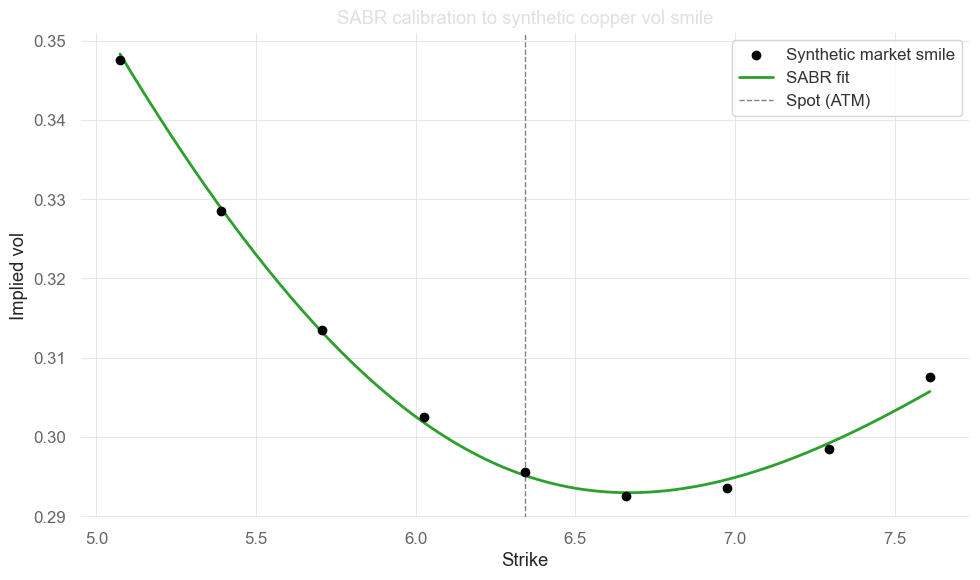

In [20]:
dc.plot_vol_smile(strikes, synthetic_vols, dense_strikes, fitted_vols, S0)
plt.tight_layout()
plt.show()